In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
datadir = '../data_porta'
datadir_original = '../en024048_hion/muram_adapt/'
grid_dir = '../en024048_hion/'
nx = 504
ny = 504
# Original nz after slicing (476 - 52 + 1)
nz_orig = 496
nz = 476 - 52 + 1
nlev = 6

In [3]:
# ---- memory–mapped arrays ----
pops_orig = np.memmap(f'{datadir}/AR_385_CaII_5L_pops.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, nlev))
b_xyz_orig = np.memmap(f'{datadir}/AR_385_B.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
temp_orig = np.memmap(f'{datadir}/AR_385_temp.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
vel_orig = np.memmap(f'{datadir}/AR_385_veloc.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
n_e_orig = np.memmap(f'{datadir}/AR_385_ne.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
n_h_orig = np.memmap(f'{datadir}/AR_385_nh.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
n_p_orig = np.memmap(f'{datadir}/AR_385_np.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))

In [4]:
z_ind_init, z_ind_final = 52, 477

In [5]:
temp = 10**fits.getdata(f'{datadir_original}BIFROST_385_logtemp.fits', ext=0)
z_coords = fits.getdata(f'{datadir_original}BIFROST_385_logtemp.fits', ext=1)
bx = fits.getdata(f'{datadir_original}BIFROST_385_bx.fits', ext=0)
by = fits.getdata(f'{datadir_original}BIFROST_385_by.fits', ext=0)
bz = fits.getdata(f'{datadir_original}BIFROST_385_by.fits', ext=0)
vx = fits.getdata(f'{datadir_original}BIFROST_385_vx.fits', ext=0)
vy = fits.getdata(f'{datadir_original}BIFROST_385_vy.fits', ext=0)
vz = fits.getdata(f'{datadir_original}BIFROST_385_vz.fits', ext=0)
n_e = 10**fits.getdata(f'{datadir_original}BIFROST_385_logne.fits', ext=0)
n_h = 10**fits.getdata(f'{datadir_original}BIFROST_385_lognh.fits', ext=0)
n_p = 10**fits.getdata(f'{datadir_original}BIFROST_385_lognp.fits', ext=0)
mass = 10**fits.getdata(f'{datadir_original}BIFROST_385_logmass.fits', ext=0)
press = 10**fits.getdata(f'{datadir_original}BIFROST_385_logpressure.fits', ext=0)

In [6]:
# Example data
temp[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_temp.dat')
n_e[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_ne.dat')
n_h[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_nh.dat')
n_p[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_np.dat')
mass[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_mass.dat')
press[z_ind_init:z_ind_final, : , : , np.newaxis].astype('<f4').tofile(f'{datadir_original}AR_385_press.dat')
np.stack([bx, by, bz], axis=-1)[z_ind_init:z_ind_final, : , :, :].astype('<f4').tofile(f'{datadir_original}AR_385_B.dat')
np.stack([vx, vy, vz], axis=-1)[z_ind_init:z_ind_final, : , :, :].astype('<f4').tofile(f'{datadir_original}AR_385_veloc.dat')

In [7]:
geometry_file = f'{grid_dir}grid_bifrost.npz'
geometry_grid = np.load(geometry_file)["z"]
geometry_file_cutted = f'{grid_dir}grid_bifrost_cutted.npz'
geometry_grid_cutted = np.load(geometry_file_cutted)["z"]

Loaded geometry grid from ../en024048_hion/grid_bifrost.npz


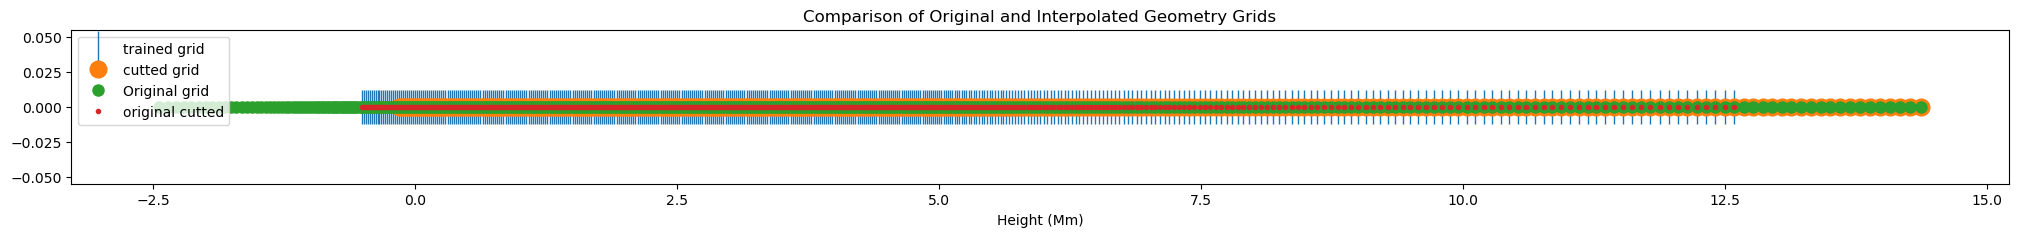

In [8]:
print(f"Loaded geometry grid from {geometry_file}")
plt.figure(figsize=(25, 2))
plt.plot(geometry_grid, geometry_grid * 0, '|', markersize=25, label='trained grid')
plt.plot(geometry_grid_cutted, geometry_grid_cutted * 0, 'o', markersize=12 ,label='cutted grid')
plt.plot(z_coords, z_coords * 0, '.', markersize=16 ,label='Original grid')
plt.plot(z_coords[z_ind_init:z_ind_final], z_coords[z_ind_init:z_ind_final] * 0, '.', markersize=6 ,label='original cutted')
plt.xlabel('Height (Mm)')
plt.legend()
plt.title('Comparison of Original and Interpolated Geometry Grids')
plt.show()